# Spectral Clustering

- Alec Campos Aoki: 15436800
- Pedro Augusto Ferraro Paffaro: 15483380

## Introdução
Spectral Clustering é um algoritmo de aprendizado de máquina não supervisionado para formar agrupamento entre dados similares. A técnica baseia-se na utilização de autovetores de uma matriz de similaridade para realizar esse agrupamento.

Diferente de técnicas clássicas, como o k-means, que dependem de distâncias diretas no espaço original, o Spectral Clustering constrói um grafo de similaridade, onde cada ponto de dado é representado como um nó, e as similaridades entre eles são representadas por arestas.

A partir desse grafo, calcula-se a matriz Laplaciana, cuja estrutura espectral (autovalores e autovetores) permite projetar os dados em um espaço de dimensões reduzidas, onde os agrupamentos ficam mais evidentes. Esse procedimento possibilita detectar clusters com formas complexas e não lineares, que seriam difíceis de identificar com métodos tradicionais.




## Clustering

Clustering é uma das técnicas mais utilizadas para análise exploratória de dados, sendo amplamente utilizado em anáises estatísticas, em aplicações biológicas e de ciências sociais, e aplicações na computação. O algoritmo segue o modelo de aprendizado de máquina não supervisionado, organizando e classificando diferentes objetos, pontos de dados ou observações em grupos com base em semelhanças ou padrões.

O Spectral Clustering, em português Agrupamento Espectral, é uma variação do Clustering, pois utiliza a conectividade entre os objetos para formar o agrupamento.


## Grafos de Similaridade

Um grafo de similaridade é uma representação matemática das relações de similaridade entre um conjunto de objetos. Seja $G = (V, E)$ um grafo não direcionado, em que cada vértice $v_i \in V$ representa um objeto (ou ponto de dados) e cada aresta $(v_i, v_j) \in E$ representa uma relação de similaridade entre dois objetos.

A similaridade entre os vértices $i$ e $j$ é expressa por um valor real não negativo $s_{ij}$. Valores maiores de $s_{ij}$ indicam maior similaridade entre $x_i$ e $x_j$. Se não houver conexão entre os vértices $i$ e $j$, define-se $s_{ij} = 0$. Para esse trabalho, qualquer relação entre dois nós de um grafo assumirá valor de similaridade igual a 1.

A matriz de similaridade (ou matriz de adjacência) $A \in \mathbb{R}^{n \times n}$ é então dada por: $$A_{ij}=s_{ij}$$
Como a relação de similaridade é simétrica, temos $A_{ij} = A_{ji}$, de modo que $A$ é uma matriz simétrica.


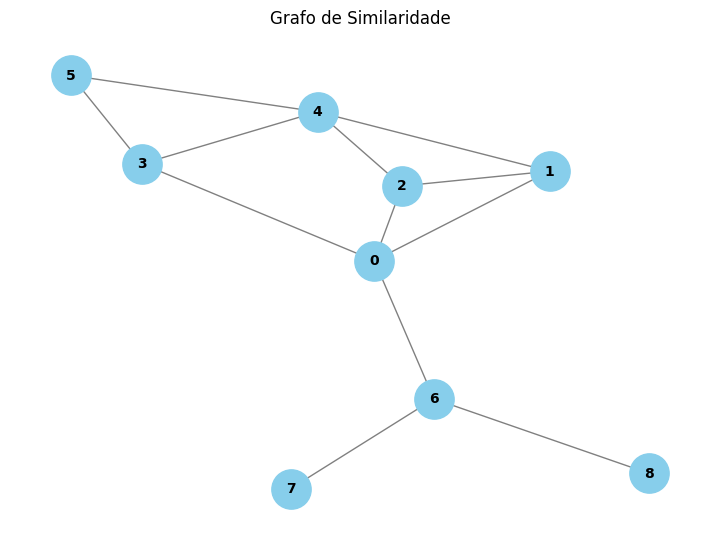

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Adjacency matrix of a graph
A = np.array([
        [0, 1, 1, 1, 0, 0, 1, 0, 0],
        [1, 0, 1, 0, 1, 0, 0, 0, 0],
        [1, 1, 0, 0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0]
    ])

G = nx.from_numpy_array(A)

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(7, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_color="skyblue",
    node_size=800,
    edge_color="gray",
    font_size=10,
    font_weight="bold"
)

plt.title("Grafo de Similaridade")
plt.show()

## Matriz de Grau

A matriz de grau de um grafo $G$ é uma matriz diagonal $n \times n$ onde cada elemento na diagonal $d_{ii}$ indica quantas conexões o nó $i$ possui (o número de conexões de um nó é chamado de grau do nó).


In [ ]:
def find_degree_matrix(A):
    """
        Function that finds the degree matrix of a graph.

        Parameters:
        - A: adjacency matrix of a graph

        Returns:
        - degree_matrix: the degree matrix of the graph (diagonal matrix with node degrees)
    """
    degree_matrix = np.zeros((len(A), len(A)))

    def find_node_degree(A, node):
        return sum(A[node])

    for i in range(len(A)):
        degree_matrix[i][i] = find_node_degree(A, i)

    return degree_matrix

D = find_degree_matrix(A)
print(D)

[[4. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 3. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 3. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 3. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 4. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 3. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]


## Matriz Laplaciana

A matriz Laplaciana do grafo é dada por: $$L = D-A$$
A matriz $L$ é simétrica e semidefinida positiva, o que significa que todos os seus autovalores são não negativos.

### Interpretação da matriz Laplaciana e do vetor $f$

Para um vetor $f \in \mathbb{R}^n$, cujas entradas $f_i$ representam valores associados aos vértices do grafo, a forma quadrática da Laplaciana é dada por:
$$ f^TLf = \frac{1}{2} \sum_{i,j} A_{ij}(f_i - f_j)^2. $$
Esse termo mede o quanto os valores de $f$ variam ao longo das arestas: quanto mais semelhantes dois nós conectados ($A_{ij}$ grande), menor deve ser a diferença entre $f_i$ e $f_j$ para minimizar $f^TLf$.

Nesse contexto, o vetor $f$ é usado para representar uma partição dos vértices.  
Se definirmos
$$
f_i =
\begin{cases}
+1, & \text{se o vértice } i \in A,\\
-1, & \text{se o vértice } i \in B,
\end{cases}
$$
temos que o corte entre os conjuntos $A$ e $B$ pode ser expresso como:
$$
\text{cut}(A, B) = \frac{1}{4} f^TLf.
$$

A minimização de $f^TLf$sob restrições apropriadas leva ao problema de autovalores generalizado:
$$
Lf = \lambda D f,
$$
cuja solução fornece os autovetores associados aos menores autovalores da Laplaciana.  
Esses autovetores definem as direções de menor variação sobre o grafo e são utilizados para identificar as partições naturais dos dados.


In [ ]:
L = D - A
print("L =", L)

def find_eigenvectors(L, k):
    """
        Function that finds the first k eigenvectors of the Laplacian matrix.

        Parameters:
        - L: Laplacian matrix of a graph
        - k: number of eigenvectors to return

        Returns:
        - eigenvectors: matrix containing the k eigenvectors as columns
    """
    eigenvals, eigenvecs = np.linalg.eig(L)
    idx = np.argsort(eigenvals)[:k]

    return eigenvecs[:, idx]

# Number of clusters
k = 3
U = find_eigenvectors(L, k)
print("U =", U)

L = [[ 4. -1. -1. -1.  0.  0. -1.  0.  0.]
 [-1.  3. -1.  0. -1.  0.  0.  0.  0.]
 [-1. -1.  3.  0. -1.  0.  0.  0.  0.]
 [-1.  0.  0.  3. -1. -1.  0.  0.  0.]
 [ 0. -1. -1. -1.  4. -1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.  2.  0.  0.  0.]
 [-1.  0.  0.  0.  0.  0.  3. -1. -1.]
 [ 0.  0.  0.  0.  0.  0. -1.  1.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.  1.]]
U = [[-3.33333333e-01  9.39550147e-02 -1.09683480e-18]
 [-3.33333333e-01  2.19788946e-01  3.23950976e-17]
 [-3.33333333e-01  2.19788946e-01 -9.44770543e-17]
 [-3.33333333e-01  2.55779585e-01  1.84796304e-16]
 [-3.33333333e-01  2.74982616e-01  3.42439239e-17]
 [-3.33333333e-01  3.16193456e-01  5.25891561e-17]
 [-3.33333333e-01 -3.49734600e-01 -1.62444067e-16]
 [-3.33333333e-01 -5.15376982e-01 -7.07106781e-01]
 [-3.33333333e-01 -5.15376982e-01  7.07106781e-01]]


A matriz de autovetores $U \in \mathbb{R}^{n \times k}$ contém, em cada linha $i$, a representação espectral do nó $i$.
Cada linha $u_i = (U_{i1}, U_{i2}, \dots, U_{ik})$ representa o nó $i$ no espaço definido pelos $k$ menores autovalores da matriz Laplaciana.
Nessa nova base, nós fortemente conectados no grafo original tendem a apresentar vetores semelhantes.

## $\textit{K-Means}$

O algoritmo $\textit{k-means}$ é uma técnica de agrupamento baseada em particionamento que visa dividir um conjunto de dados em $k$ grupos distintos.
Dado um conjunto de pontos ${x_1, x_2, \dots, x_n}$, o método busca minimizar a soma das distâncias quadráticas entre cada ponto e o centro ($\textit{centroide}$) do grupo ao qual ele pertence.

O processo é iterativo e envolve duas etapas principais:

    Atribuição: cada ponto é associado ao centroide mais próximo;
    Atualização: os centroides são recalculados como a média dos pontos atribuídos a cada grupo.

No contexto do spectral clustering, o $\textit{k-means}$ é aplicado às linhas da matriz de autovetores $U$, tratando cada linha como a representação espectral de um nó.
Dessa forma, os grupos formados correspondem a subconjuntos de nós fortemente conectados no grafo original.

In [ ]:
def k_means(U, k, max_iters=100, tol=1e-4):
    """
        Function that performs k-means clustering on the rows of a matrix.

        Parameters:
        - U: data matrix where each row is a data point (e.g., rows of eigenvectors)
        - k: number of clusters
        - max_iters: maximum number of iterations
        - tol: tolerance for centroid convergence

        Returns:
        - labels: array of cluster assignments for each row
        - centroids: final centroids of the clusters
    """
    lines, _ = U.shape

    centroids = U[np.random.choice(lines, k, replace=False)]

    for _ in range(max_iters):
        distances = np.linalg.norm(U[:, None] - centroids[None, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([U[labels==i].mean(axis=0) for i in range(k)])

        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    return labels, centroids

## Spectral Clustering Não Normalizado

O primeiro algoritmo, e mais simples, da família do spectral clustering, é o algoritmo não normalizado.

Ele simplesmente determina as matrizes de grau $D$, a laplaciana $L$ e a matriz dos autovetores $U$ e aplica o algoritmo de $\textit{k-means}$ nesta última para finalizar o agrupamento.

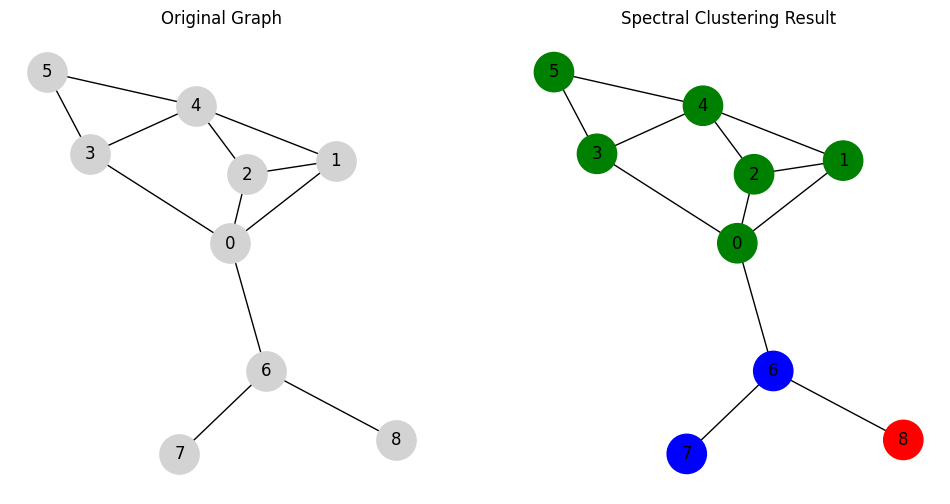

In [ ]:
def unnormalized_spectral_clustering(A, k):
    """
        Function that performs unnormalized spectral clustering on a graph.

        Parameters:
        - A: adjacency matrix of a graph
        - k: number of clusters

        Returns:
        - None
    """
    G = nx.from_numpy_array(A)

    # Compute Laplacian and eigenvectors
    D = find_degree_matrix(A)
    L = D - A
    U = find_eigenvectors(L, k)

    # Apply k-means
    labels, _ = k_means(U, k)
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    node_colors = [colors[labels[i]] for i in range(len(labels))]

    # Create a layout for the graph (same for both plots)
    pos = nx.spring_layout(G, seed=42)

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Left: original graph
    nx.draw(G, pos=pos, with_labels=True, ax=axes[0], node_color='lightgray', node_size=800)
    axes[0].set_title("Original Graph")

    # Right: clustered graph
    nx.draw(G, pos=pos, with_labels=True, ax=axes[1], node_color=node_colors, node_size=800)
    axes[1].set_title("Spectral Clustering Result")

    plt.show()

unnormalized_spectral_clustering(A, k)

## Spectral Clustering Normalizado segundo Ng, Jordan e Weiss

Diferentemente do algoritmo não normalizado, o algoritmo normalizado calcula a matriz laplaciana normalizada, definida por: $$L = I - D^{-1/2}AD^{-1/2}$$
Essa normalização garante que nós com diferentes graus tenham influência proporcional, tornando o algoritmo mais estável.

Outro contraponto em relação ao algoritmo não normalizado é a normalização da matriz de autovetores $U$, que também torna o algoritmo mais estável e consistente: $$u_{\text{norm}_{ij}}=\frac{u_{ij}}{\sqrt{\sum_k u^2_{ik}}}$$

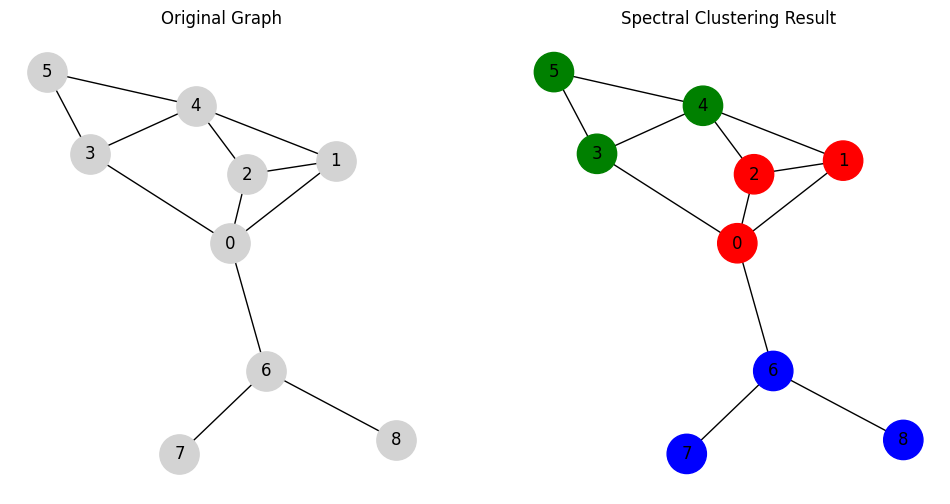

In [ ]:
def find_normalized_laplacian(A):
    """
        Function that finds the normalized Laplacian matrix of a graph.

        Parameters:
        - A: adjacency matrix of a graph

        Returns:
        - L: normalized Laplacian matrix of the graph
    """
    D = find_degree_matrix(A)
    deg = np.diag(D)

    # Compute D^{-1/2}, handling zero degrees
    with np.errstate(divide='ignore'):
        inv_sqrt_deg = 1.0 / np.sqrt(deg)
    inv_sqrt_deg[np.isinf(inv_sqrt_deg)] = 0.0

    D_inv_sqrt = np.diag(inv_sqrt_deg)

    # Normalized Laplacian
    L = np.eye(len(A)) - D_inv_sqrt @ A @ D_inv_sqrt

    return L


def normalized_spectral_clustering(A, k):
    """
        Function that performs normalized spectral clustering on a graph.

        Parameters:
        - A: adjacency matrix of a graph
        - k: number of clusters

        Returns:
        - None
    """
    G = nx.from_numpy_array(A)

    # Compute normalized Laplacian and eigenvectors
    L = find_normalized_laplacian(A)
    U = find_eigenvectors(L, k)

    # Normalize each row of U
    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    U_normalized = U / row_norms

    # Apply k-means on normalized U
    labels, _ = k_means(U_normalized, k)
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    node_colors = [colors[labels[i]] for i in range(len(labels))]

    # Create a layout for the graph (same for both plots)
    pos = nx.spring_layout(G, seed=42)

    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Left: original graph
    nx.draw(G, pos=pos, with_labels=True, ax=axes[0], node_color='lightgray', node_size=800)
    axes[0].set_title("Original Graph")

    # Right: clustered graph
    nx.draw(G, pos=pos, with_labels=True, ax=axes[1], node_color=node_colors, node_size=800)
    axes[1].set_title("Spectral Clustering Result")

    plt.show()


normalized_spectral_clustering(A, k)



## Diferenças entre o Algoritmo Normalizado e o Não Normalizado

No algoritmo normalizado, normalização atua em dois níveis — na Laplaciana e nos autovetores — tornando o algoritmo mais robusto e menos dependente de magnitudes e inicializações aleatórias. Porém, o algoritmo não normalizado pode gerar agrupamentos enviesados e instáveis, uma vez que o k-means será influenciado mais pelas colunas de maior escala do que pela estrutura real dos dados.

## Spectral Clustering Probabilístico
O spectral clustering probabilístico baseia-se em uma interpretação de caminhos aleatórios em um grafo. A partir da matriz de adjacência $A$, calcula-se a matriz de transição:$$P = D^{-1}A$$
Cada elemento $P_{ij}$representa a probabilidade de transitar do nó $i$ para o nó $j$.

Define-se a matriz laplaciana de passeio aleatório $L_{rw}$ por: $$L_{rw} = I - P$$

Os primeiros $k$ autovetores de $L_{rw}$ capturam os modos principais de transição, formando uma matriz de características para os nós. Normalizando cada linha, aplica-se o $\textit{k-means}$ para agrupar os nós de acordo com a probabilidade de permanecer dentro de regiões densamente conectadas.



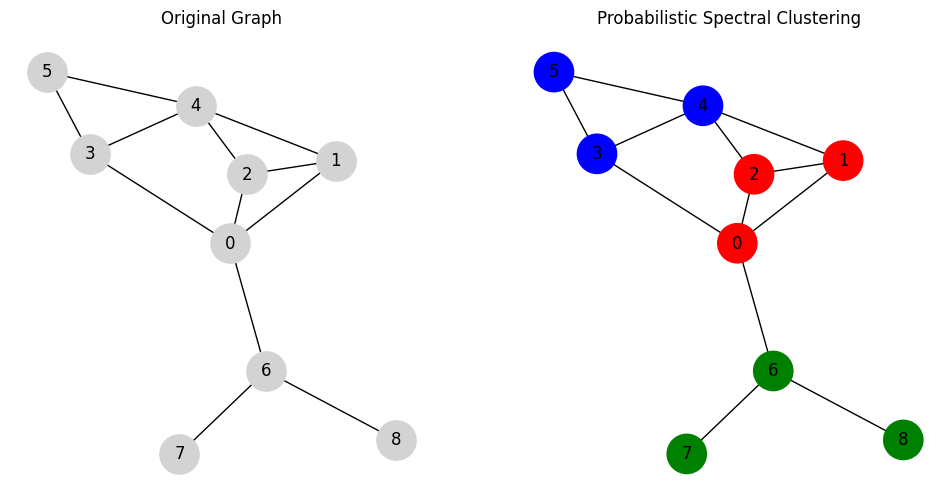

In [ ]:
def probabilistic_spectral_clustering(A, k):
    """
        Function that performs probabilistic spectral clustering on a graph.

        Parameters:
        - A: adjacency matrix of a graph
        - k: number of clusters

        Returns:
        - None (plots the original and clustered graph)
    """
    G = nx.from_numpy_array(A)

    D = find_degree_matrix(A)
    deg = np.diag(D)
    inv_deg = np.zeros_like(deg, dtype=float)
    inv_deg[deg != 0] = 1.0 / deg[deg != 0]

    D_inv = np.diag(inv_deg)

    L_rw = np.eye(len(A)) - D_inv @ A

    U = find_eigenvectors(L_rw, k)

    row_norms = np.linalg.norm(U, axis=1, keepdims=True)
    U_normalized = U / row_norms

    labels, _ = k_means(U_normalized, k)
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    node_colors = [colors[labels[i]] for i in range(len(labels))]

    pos = nx.spring_layout(G, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    nx.draw(G, pos=pos, with_labels=True, ax=axes[0],
            node_color='lightgray', node_size=800)
    axes[0].set_title("Original Graph")

    nx.draw(G, pos=pos, with_labels=True, ax=axes[1],
            node_color=node_colors, node_size=800)
    axes[1].set_title("Probabilistic Spectral Clustering")

    plt.show()

probabilistic_spectral_clustering(A, k)
